In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded')

Libraries loaded


In [4]:
athletes_df = pd.read_csv('athlete_events.csv')
medals_country_df = pd.read_csv('Olympics (1896-2024).csv')
noc_region_df = pd.read_csv('noc_regions.csv')


In [5]:
print('Athletes dataset shape:', athletes_df.shape)
print('Country medals dataset shape:', medals_country_df.shape)


Athletes dataset shape: (271116, 15)
Country medals dataset shape: (1436, 7)


In [10]:
merged_df = athletes_df.merge(medals_country_df, on='NOC', how='left')

print('Merged dataset shape:', merged_df.shape)
merged_df.head()

Merged dataset shape: (271116, 21)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year_x,...,City,Sport,Event,Medal,Year_y,Rank,Gold,Silver,Bronze,Total
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,...,Barcelona,Basketball,Basketball Men's Basketball,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,...,London,Judo,Judo Men's Extra-Lightweight,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,...,Antwerpen,Football,Football Men's Football,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,...,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,...,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
swimming_df = athletes_df[athletes_df['Sport'] == 'Swimming'].copy()
print('Full dataset rows:', athletes_df.shape[0])
print('Swimming only rows:', swimming_df.shape[0])


Full dataset rows: 271116
Swimming only rows: 23195


In [14]:
swimming_df = merged_df[
    (merged_df['Sport'] == 'Swimming') &
    (merged_df['Year_x'] >= 1924)
].copy()
print('Swimming dataset shape:', swimming_df.shape)
swimming_df['Medal'] = swimming_df['Medal'].fillna('None')
print('Medal distribution in swimming dataset:')
print(swimming_df['Medal'].value_counts())


Swimming dataset shape: (22344, 21)
Medal distribution in swimming dataset:
Medal
None      19518
Gold       1025
Silver      917
Bronze      884
Name: count, dtype: int64


In [15]:
#See all unique swimming events 
print(swimming_df['Event'].unique())
print('\nTotal unique events:', swimming_df['Event'].nunique())

["Swimming Men's 400 metres Freestyle"
 "Swimming Men's 200 metres Breaststroke"
 "Swimming Men's 100 metres Butterfly"
 "Swimming Men's 200 metres Butterfly"
 "Swimming Men's 4 x 100 metres Medley Relay"
 "Swimming Men's 100 metres Freestyle"
 "Swimming Men's 4 x 200 metres Freestyle Relay"
 "Swimming Men's 50 metres Freestyle"
 "Swimming Men's 100 metres Backstroke"
 "Swimming Women's 100 metres Backstroke"
 "Swimming Women's 200 metres Backstroke"
 "Swimming Women's 4 x 100 metres Medley Relay"
 "Swimming Women's 50 metres Freestyle"
 "Swimming Men's 200 metres Freestyle"
 "Swimming Men's 4 x 100 metres Freestyle Relay"
 "Swimming Men's 200 metres Backstroke"
 "Swimming Men's 200 metres Individual Medley"
 "Swimming Men's 400 metres Individual Medley"
 "Swimming Women's 4 x 100 metres Freestyle Relay"
 "Swimming Men's 1,500 metres Freestyle"
 "Swimming Women's 100 metres Freestyle"
 "Swimming Women's 200 metres Butterfly"
 "Swimming Women's 400 metres Individual Medley"
 "Swimming W

In [17]:
selected_events = [
    "Swimming Men\'s 200 metres Freestyle",
    "Swimming Women\'s 200 metres Freestyle",
    "Swimming Men\'s 200 metres Butterfly",
    "Swimming Women\'s 200 metres Butterfly"]
swimming_selected_df = swimming_df[swimming_df['Event'].isin(selected_events)].copy()
print('Selected swimming events dataset shape:', swimming_selected_df.shape)
print('Medal distribution in selected swimming events dataset:')
print('Rows per event:')
for event in selected_events:
    print(f"{event}: {swimming_selected_df[swimming_selected_df['Event'] == event].shape[0]}")
print(swimming_selected_df['Event'].value_counts())



Selected swimming events dataset shape: (2114, 21)
Medal distribution in selected swimming events dataset:
Rows per event:
Swimming Men's 200 metres Freestyle: 671
Swimming Women's 200 metres Freestyle: 497
Swimming Men's 200 metres Butterfly: 568
Swimming Women's 200 metres Butterfly: 378
Event
Swimming Men's 200 metres Freestyle      671
Swimming Men's 200 metres Butterfly      568
Swimming Women's 200 metres Freestyle    497
Swimming Women's 200 metres Butterfly    378
Name: count, dtype: int64


In [18]:

print('Missing values before handling:')
print(swimming_selected_df.isnull().sum())

Missing values before handling:
ID           0
Name         0
Sex          0
Age         15
Height     192
Weight     211
Team         0
NOC          0
Games        0
Year_x       0
Season       0
City         0
Sport        0
Event        0
Medal        0
Year_y    2114
Rank      2114
Gold      2114
Silver    2114
Bronze    2114
Total     2114
dtype: int64


In [21]:
swimming_selected_df['Age'].fillna(swimming_selected_df['Age'].median(), inplace=True)
swimming_selected_df['Height'].fillna(swimming_selected_df['Height'].median(), inplace=True)
swimming_selected_df['Weight'].fillna(swimming_selected_df['Weight'].median(), inplace=True)

print('Missing values after handling:')
print(swimming_selected_df.isnull().sum())

Missing values after handling:
ID              0
Name            0
Sex             0
Age             0
Height          0
Weight          0
Team            0
NOC             0
Games           0
Year_x          0
Season          0
City            0
Sport           0
Event           0
Medal           0
Year_y       2114
Rank         2114
Gold         2114
Silver       2114
Bronze       2114
Total        2114
Medal_Won       0
dtype: int64


In [22]:
swimming_selected_df['Medal_Won'] = (swimming_selected_df['Medal'] != 'None').astype(int)
swimming_selected_df = swimming_selected_df.sort_values(['ID', 'Year_x']).reset_index(drop=True)

In [25]:
swimming_selected_df['Previous_Appearances'] = swimming_selected_df.groupby('ID').cumcount()

swimming_selected_df['Cumulative_Medals_Before'] = (
    swimming_selected_df.groupby('ID')['Medal_Won']
    .cumsum()
    .shift(fill_value=0)
)

swimming_selected_df['Previous_Medal'] = (
    swimming_selected_df['Cumulative_Medals_Before'] > 0
).astype(int)
swimming_selected_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year_x,...,Silver,Bronze,Total,Medal_Won,Previous_Appearances,Cumulative_Medals_Before,Previous_Medal,NOC_enc,Sex_enc,Event_enc
0,36,Stefan Remco Aartsen,M,21.0,194.0,78.0,Netherlands,NED,1996 Summer,1996,...,NaN,NaN,NaN,0,0,0,0,83,1,0
1,36,Stefan Remco Aartsen,M,25.0,194.0,78.0,Netherlands,NED,2000 Summer,2000,...,NaN,NaN,NaN,0,1,0,0,83,1,0
2,317,Roosevelt M. Abdulgafur,M,24.0,181.0,73.0,Philippines,PHI,1968 Summer,1968,...,NaN,NaN,NaN,0,0,0,0,90,1,1
3,322,Ahmed Ghanim Abdullah,M,20.0,184.0,79.0,Egypt,EGY,1988 Summer,1988,...,NaN,NaN,NaN,0,0,0,0,32,1,0
4,558,David Abrard,M,19.0,187.0,81.0,France,FRA,1996 Summer,1996,...,NaN,NaN,NaN,0,0,0,0,39,1,0


In [26]:
le = LabelEncoder()
swimming_selected_df['NOC_enc'] = le.fit_transform(swimming_selected_df['NOC'])
swimming_selected_df['Sex_enc'] = le.fit_transform(swimming_selected_df['Sex'])
swimming_selected_df['Event_enc'] = le.fit_transform(swimming_selected_df['Event'])
swimming_selected_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year_x,...,Silver,Bronze,Total,Medal_Won,Previous_Appearances,Cumulative_Medals_Before,Previous_Medal,NOC_enc,Sex_enc,Event_enc
0,36,Stefan Remco Aartsen,M,21.0,194.0,78.0,Netherlands,NED,1996 Summer,1996,...,NaN,NaN,NaN,0,0,0,0,83,1,0
1,36,Stefan Remco Aartsen,M,25.0,194.0,78.0,Netherlands,NED,2000 Summer,2000,...,NaN,NaN,NaN,0,1,0,0,83,1,0
2,317,Roosevelt M. Abdulgafur,M,24.0,181.0,73.0,Philippines,PHI,1968 Summer,1968,...,NaN,NaN,NaN,0,0,0,0,90,1,1
3,322,Ahmed Ghanim Abdullah,M,20.0,184.0,79.0,Egypt,EGY,1988 Summer,1988,...,NaN,NaN,NaN,0,0,0,0,32,1,0
4,558,David Abrard,M,19.0,187.0,81.0,France,FRA,1996 Summer,1996,...,NaN,NaN,NaN,0,0,0,0,39,1,0


In [30]:
Features = [
    'Age', 'Height', 'Weight',
    'Sex_enc', 'Event_enc', 'NOC_enc',
    'Previous_Appearances',
    'Cumulative_Medals_Before',
    'Previous_Medal'
]

Target = 'Medal_Won'

X = swimming_selected_df[Features]
y = swimming_selected_df[Target]

print('Features shape:', X.shape)
print('Target distribution:')
print(y.value_counts())




Features shape: (2114, 9)
Target distribution:
Medal_Won
0    1949
1     165
Name: count, dtype: int64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 1691
Test rows: 423


In [32]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


In [33]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))

              precision    recall  f1-score   support

    No Medal       0.93      0.99      0.96       390
       Medal       0.50      0.15      0.23        33

    accuracy                           0.92       423
   macro avg       0.72      0.57      0.60       423
weighted avg       0.90      0.92      0.90       423



In [41]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        random_state=42
    )
}

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print(f'\n                        {name}              ')
    print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))
    print(f'AUC Score: {auc:.4f}')


                        Random Forest              
              precision    recall  f1-score   support

    No Medal       0.93      0.99      0.96       390
       Medal       0.50      0.15      0.23        33

    accuracy                           0.92       423
   macro avg       0.72      0.57      0.60       423
weighted avg       0.90      0.92      0.90       423

AUC Score: 0.8018

                        Gradient Boosting              
              precision    recall  f1-score   support

    No Medal       0.93      0.99      0.96       390
       Medal       0.44      0.12      0.19        33

    accuracy                           0.92       423
   macro avg       0.69      0.55      0.57       423
weighted avg       0.89      0.92      0.90       423

AUC Score: 0.8069


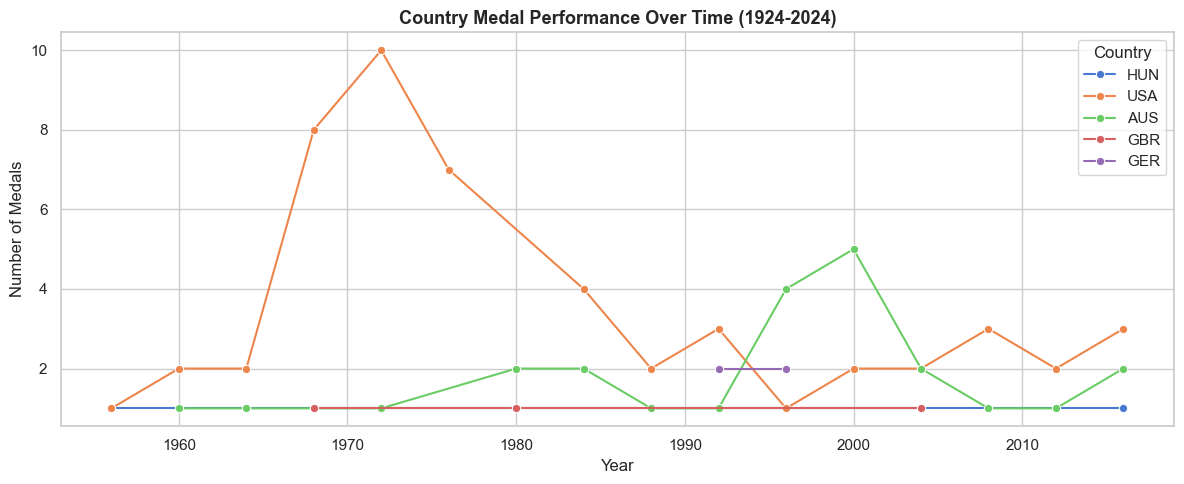

In [42]:
#country medal performance over time 
top_countries = ['USA', 'AUS', 'GBR', 'GER', 'HUN']

country_time = swimming_selected_df[
    (swimming_selected_df['NOC'].isin(top_countries)) &
    (swimming_selected_df['Medal_Won'] == 1)
].groupby(['Year_x', 'NOC']).size().reset_index(name='Medal_Count')

plt.figure(figsize=(12, 5))
sns.lineplot(data=country_time, x='Year_x', y='Medal_Count', 
             hue='NOC', marker='o')
plt.title('Country Medal Performance Over Time (1924-2024)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.legend(title='Country')
plt.tight_layout()
plt.show()